# Network Intrusion Detection — A Teaching Walkthrough

**Module:** STW7072CEM Machine Learning  
**Author:** Sudip Adhikari (250578)  
**Institution:** Softwarica College of IT & E-Commerce (Coventry University)

This notebook is the runnable companion to the paper. Unlike a typical
results-only notebook, every stage of the pipeline shows **what the data
looks like before and after** so the reader can build an intuition for what
the transformations do, not just trust them.

**The story we will tell:**

1. Load NSL-KDD and inspect the raw connection records.
2. Understand the labels — how 22 attack subtypes collapse to 5 classes.
3. See the categorical and numeric columns in their raw form.
4. Apply one-hot encoding and standardisation, and see the result.
5. See class imbalance, then balance it with SMOTE.
6. Train three models (Logistic Regression, Random Forest, XGBoost) under
   identical conditions, with per-fold SMOTE.
7. Compare them — overall and per class — and explain *why* the test scores
   are so much lower than the cross-validation scores.
8. Inspect predictions, confusion matrices, and feature importances.

---
## Step 0 — Setup

Before running this notebook:

1. `pip install -r ../requirements.txt`
2. (macOS only) `brew install libomp` for XGBoost
3. Place `KDDTrain+.txt` and `KDDTest+.txt` under
   `../dataset/archive/nsl-kdd/`. Download links: 
   <https://www.kaggle.com/datasets/hassan06/nslkdd>

In [15]:
# Make src/ importable so we can re-use the same code that the
# command-line script and the paper rely on.
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from config import CLASS_LABELS, CV_FOLDS, RANDOM_SEED, ATTACK_TO_CATEGORY
from data_loader import load_nsl_kdd, class_distribution
from preprocess import full_pipeline
from models import build_models
from evaluate import overall_metrics, per_class_table

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
print(f'Imports OK. Random seed: {RANDOM_SEED}')

Imports OK. Random seed: 42


---
## Step 1 — Load the raw NSL-KDD data

**About the train/test split.** This is an important point for the
assignment. NSL-KDD is shipped *pre-split* by its creators (Tavallaee et al.,
2009): `KDDTrain+.txt` is the training set, `KDDTest+.txt` is the held-out
test set. We do **not** generate the split ourselves with
`train_test_split` — using the official split is what makes the benchmark
comparable across studies.

An additional design choice in NSL-KDD is that the test set deliberately
contains some attack subtypes that are absent or under-represented in the
training set. This is what makes the benchmark realistic: in the real world,
an attacker rarely uses the exact same exploit you trained on.

Cross-validation (5-fold) is then run *inside* the training set only —
we never look at `KDDTest+.txt` until the very end.

In [16]:
train_df, test_df = load_nsl_kdd()
print(f'Training records: {len(train_df):>7,}')
print(f'Test records:     {len(test_df):>7,}')
print(f'Total columns:    {train_df.shape[1]} (41 features + label + difficulty score)')

Training records: 125,973
Test records:      22,544
Total columns:    42 (41 features + label + difficulty score)


### What does a single connection record look like?

Each row in NSL-KDD describes one network connection (a TCP/UDP/ICMP
session) summarised across 41 features. Below is the first row, transposed
so you can read every field at once.

In [17]:
# Show the first connection record, transposed for readability
train_df.head(1).T

,0
duration,0
protocol_type,tcp
service,ftp_data
flag,SF
src_bytes,491
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


The 41 features fall into four families:

1. **Basic features (1–9):** properties of the TCP/IP connection itself —
   `duration`, `protocol_type`, `service`, `flag`, byte counts.
2. **Content features (10–22):** payload-related signals — `failed_logins`,
   `root_shell`, `num_file_creations`, etc.
3. **Time-window traffic features (23–31):** statistics over a 2-second
   window — `count`, `serror_rate`, `same_srv_rate`.
4. **Host-based traffic features (32–41):** statistics over the past 100
   connections to the same host.

Three of these features are categorical (text), the rest are numeric.

In [18]:
# A quick look at the first five training rows in tabular form
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,...,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,...,0.0000,1.0000,0.0000,0.0000,150,25,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,Normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,...,0.0000,0.0800,0.1500,0.0000,255,1,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,...,0.0000,0.0500,0.0700,0.0000,255,26,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,...,0.0000,1.0000,0.0000,0.0000,30,255,1.0000,0.0000,0.0300,0.0400,0.0300,0.0100,0.0000,0.0100,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,...,0.0000,1.0000,0.0000,0.0900,255,255,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Normal


In [19]:
# Data types — three text columns, the rest numeric
print(train_df.dtypes.value_counts())
print()
print('Categorical (object) columns:')
print(train_df.select_dtypes(include='object').columns.tolist())

int64      23
float64    15
str         4
Name: count, dtype: int64

Categorical (object) columns:
['protocol_type', 'service', 'flag', 'label']


/var/folders/r9/n5tlr3r9771872jz_p4txtn80000gn/T/ipykernel_84890/2494626153.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train_df.select_dtypes(include='object').columns.tolist())


### Numeric summary of the training set

`describe()` gives the basic statistics of every numeric column. Notice the
huge differences in scale: `duration` ranges into the tens of thousands,
while many rate features are in `[0, 1]`. This is *why* we will need to
standardise before training Logistic Regression — without it, the linear
model would be dominated by the large-scale columns.

In [20]:
train_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
duration,125973.0000,287.1447,2604.5153,0.0000,0.0000,0.0000,0.0000,42908.0000
src_bytes,125973.0000,45566.7430,5870331.1819,0.0000,0.0000,44.0000,276.0000,1379963888.0000
dst_bytes,125973.0000,19779.1144,4021269.1514,0.0000,0.0000,0.0000,516.0000,1309937401.0000
land,125973.0000,0.0002,0.0141,0.0000,0.0000,0.0000,0.0000,1.0000
wrong_fragment,125973.0000,0.0227,0.2535,0.0000,0.0000,0.0000,0.0000,3.0000
urgent,125973.0000,0.0001,0.0144,0.0000,0.0000,0.0000,0.0000,3.0000
hot,125973.0000,0.2044,2.1500,0.0000,0.0000,0.0000,0.0000,77.0000
num_failed_logins,125973.0000,0.0012,0.0452,0.0000,0.0000,0.0000,0.0000,5.0000
logged_in,125973.0000,0.3957,0.4890,0.0000,0.0000,0.0000,1.0000,1.0000
num_compromised,125973.0000,0.2793,23.9420,0.0000,0.0000,0.0000,0.0000,7479.0000


---
## Step 2 — The labels: 22 attack types collapsed into 5 classes

NSL-KDD has 22 distinct attack labels in training (e.g. `neptune`,
`smurf`, `buffer_overflow`). Working at that granularity is impractical —
many attacks have only a handful of examples. The standard convention is to
collapse them into 5 high-level categories: `Normal`, `DoS` (denial of
service), `Probe` (reconnaissance), `R2L` (remote-to-local exploits), and
`U2R` (user-to-root privilege escalation).

The mapping from the 22 raw labels to the 5 classes is hardcoded in
`config.ATTACK_TO_CATEGORY`. Here it is:

In [23]:
# Show the 22-to-5 mapping, grouped by category
from collections import defaultdict
by_cat = defaultdict(list)
for raw, cat in ATTACK_TO_CATEGORY.items():
    by_cat[cat].append(raw)
for cat in CLASS_LABELS:
    print(f'{cat:>7s}: {sorted(by_cat[cat])}')

 Normal: ['normal']
    DoS: ['apache2', 'back', 'land', 'mailbomb', 'neptune', 'pod', 'processtable', 'smurf', 'teardrop', 'udpstorm']
  Probe: ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']
    R2L: ['ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 'snmpguess', 'spy', 'warezclient', 'warezmaster', 'worm', 'xlock', 'xsnoop']
    U2R: ['buffer_overflow', 'loadmodule', 'perl', 'ps', 'rootkit', 'sqlattack', 'xterm']


In [24]:
# Raw 22-label distribution before collapsing
raw_label_col = train_df['label'].astype(str).str.replace(r'\..*', '', regex=True)
raw_counts = raw_label_col.value_counts()
print(f'Distinct raw attack labels in training: {len(raw_counts)}')
print()
print(raw_counts.head(15))

Distinct raw attack labels in training: 5

label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


### After collapsing to 5 classes — the imbalance becomes the central problem

Look at the table below carefully. Two facts are critical:

* `Normal` and `DoS` together account for ~90 % of training rows.
* `U2R` has only **52 training samples** — that is 0.04 % of the data.
  Any model that ignores U2R entirely would still be 99.96 % accurate on
  this class (and 0 % useful).
* `R2L` jumps from 0.79 % in train to 12.81 % in test — the test set
  contains R2L variants the training set does not show. This is by design.

These two observations drive nearly every methodological choice in the
rest of the notebook: per-class metrics, SMOTE, macro F1.

In [25]:
print(class_distribution(train_df, 'train'))
print()
print(class_distribution(test_df,  'test'))

               samples  percent
class (train)                  
Normal           67343  53.4600
DoS              45927  36.4600
Probe            11656   9.2500
R2L                995   0.7900
U2R                 52   0.0400

              samples  percent
class (test)                  
Normal           9711  43.0800
DoS              7458  33.0800
R2L              2887  12.8100
Probe            2421  10.7400
U2R                67   0.3000


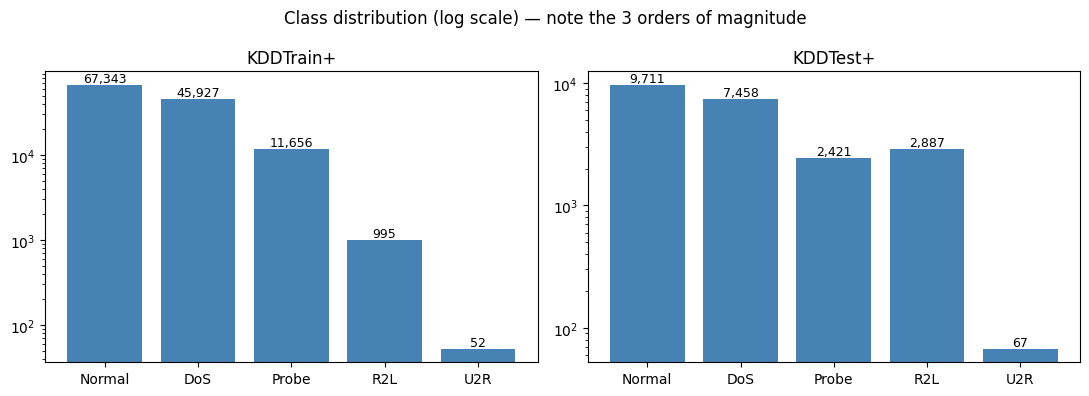

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['KDDTrain+', 'KDDTest+']):
    counts = df['label'].value_counts().reindex(CLASS_LABELS)
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_title(title); ax.set_yscale('log')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Class distribution (log scale) — note the 3 orders of magnitude')
fig.tight_layout(); plt.show()

---
## Step 3 — Look at the categorical features in their raw form

Three columns are non-numeric and cannot be fed directly into a model:
`protocol_type` (3 values), `flag` (11 values), and `service` (~70 values).
We need to convert them to numbers in a way that does not impose a false
ordering — that means **one-hot encoding**, where each value becomes its own
0/1 column.

In [27]:
for col in ['protocol_type', 'flag', 'service']:
    vals = train_df[col].value_counts()
    print(f"{col}: {len(vals)} distinct values")
    print(vals.head(8).to_string())
    print()

protocol_type: 3 distinct values
protocol_type
tcp     102689
udp      14993
icmp      8291

flag: 11 distinct values
flag
SF      74945
S0      34851
REJ     11233
RSTR     2421
RSTO     1562
S1        365
SH        271
S2        127

service: 70 distinct values
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077



### Encoding over the union of train + test

A subtle but important detail: when we one-hot encode, we use the **union**
of categories from train *and* test. If we encoded only on training, any
service string that appears for the first time in the test set (and there
are several) would get all-zero columns and silently break tree splits.

---
## Step 4 — Apply the full preprocessing pipeline

`full_pipeline` does three things in order:

1. One-hot encode the three categorical columns over the train+test union.
2. Standardise the 38 numeric columns (zero mean, unit variance) using a
   scaler fit only on the training data.
3. Encode the 5 string class labels into integers 0..4 using a single
   `LabelEncoder` fit on the union, so the same integer-to-class mapping
   is used for train and test.

Tree-based models do not require standardisation, but they are not harmed by
it; Logistic Regression *does* need it, so we do it once for everyone.

In [28]:
X_train, y_train, X_test, y_test, feature_names, label_encoder = full_pipeline(train_df, test_df)
print(f'X_train shape: {X_train.shape}  →  41 raw features became {X_train.shape[1]} after one-hot encoding')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape},  unique labels: {sorted(set(y_train))}')
print()
print('Integer → class label map (used everywhere from now on):')
for i, lbl in enumerate(label_encoder.classes_):
    print(f'  {i} → {lbl}')

X_train shape: (125973, 122)  →  41 raw features became 122 after one-hot encoding
X_test shape:  (22544, 122)
y_train shape: (125973,),  unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Integer → class label map (used everywhere from now on):
  0 → Normal
  1 → DoS
  2 → Probe
  3 → R2L
  4 → U2R


### What changed for the categorical columns?

Before encoding, the `protocol_type` column had three string values:
`tcp`, `udp`, `icmp`. After encoding, those become three 0/1 columns:
`protocol_type_tcp`, `protocol_type_udp`, `protocol_type_icmp`. Below we
look at the new columns that came from `protocol_type`.

In [29]:
# Find the columns that came from one-hot encoding protocol_type
proto_cols = [i for i, n in enumerate(feature_names) if n.startswith('protocol_type_')]
print('protocol_type_* columns produced by one-hot encoding:')
for i in proto_cols:
    print(f'  feature[{i:>3}] = {feature_names[i]}')
print()
print('Sample of those columns for the first 5 training rows:')
pd.DataFrame(X_train[:5, proto_cols], columns=[feature_names[i] for i in proto_cols])

protocol_type_* columns produced by one-hot encoding:
  feature[ 38] = protocol_type_icmp
  feature[ 39] = protocol_type_tcp
  feature[ 40] = protocol_type_udp

Sample of those columns for the first 5 training rows:


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp
0,-0.2654,0.4762,-0.3676
1,-0.2654,-2.1001,2.7207
2,-0.2654,0.4762,-0.3676
3,-0.2654,0.4762,-0.3676
4,-0.2654,0.4762,-0.3676


### What changed for the numeric columns?

Before standardisation, numeric columns lived on wildly different scales
(see the `describe()` output earlier). After standardisation, every numeric
column has approximately mean = 0 and standard deviation = 1 in the
training set.

The cell below verifies this. The first six features (after one-hot) are
the original numeric features — their mean should now be very close to 0
and their standard deviation very close to 1.

In [30]:
# The first numeric feature in the original ordering is 'duration' (index 0)
first_numeric = [i for i, n in enumerate(feature_names)
                 if not (n.startswith('protocol_type_') or n.startswith('service_') or n.startswith('flag_'))][:6]
print('Statistics of the first six numeric features (post-standardisation):')
stats = pd.DataFrame(X_train[:, first_numeric], columns=[feature_names[i] for i in first_numeric]).describe().T
print(stats[['mean', 'std', 'min', 'max']].round(3))

Statistics of the first six numeric features (post-standardisation):
                  mean    std     min      max
duration       -0.0000 1.0000 -0.1100  16.3640
src_bytes       0.0000 1.0000 -0.0080 235.0670
dst_bytes      -0.0000 1.0000 -0.0050 325.7490
land           -0.0000 1.0000 -0.0140  70.9780
wrong_fragment  0.0000 1.0000 -0.0890  11.7430
urgent          0.0000 1.0000 -0.0080 208.8190


---
## Step 5 — Class imbalance handling with SMOTE

**The problem.** The training set has 67,343 Normal rows and 52 U2R rows.
A model that just predicts Normal for every input would be 53 % accurate.
Without intervention, our gradient updates are dominated by Normal examples
and the rare classes are effectively ignored.

**The solution.** SMOTE (Synthetic Minority Over-sampling Technique,
Chawla et al., 2002) generates new synthetic minority examples by
interpolating between real minority samples and their nearest neighbours.
It is *not* simple duplication: a synthetic point sits on the line between
two real minority points, somewhere in their feature-space neighbourhood.

**The subtle bit — when to apply it.** We apply SMOTE in two places:

1. **Inside each cross-validation fold** (training side only), when we are
   measuring CV performance. This is the honest way.
2. **Once over the whole training set** when we fit the final model.

Generating SMOTE samples once *before* splitting into folds (a common
shortcut) leaks synthetic samples derived from validation neighbours back
into training and inflates the cross-validation score by several points.
We are deliberately not doing that.

In [31]:
# Class counts BEFORE SMOTE
before = pd.Series(y_train).value_counts().sort_index()
before.index = [label_encoder.classes_[i] for i in before.index]

# Apply SMOTE to the full training set (this is for the final fit only)
sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

after = pd.Series(y_train_smote).value_counts().sort_index()
after.index = [label_encoder.classes_[i] for i in after.index]

summary = pd.DataFrame({'Before SMOTE': before, 'After SMOTE': after})
summary['Synthetic added'] = summary['After SMOTE'] - summary['Before SMOTE']
print(summary)
print()
print(f'Total rows before SMOTE: {len(y_train):>7,}')
print(f'Total rows after SMOTE:  {len(y_train_smote):>7,}  (5 × {before.max():,})')

        Before SMOTE  After SMOTE  Synthetic added
Normal         67343        67343                0
DoS            45927        67343            21416
Probe          11656        67343            55687
R2L              995        67343            66348
U2R               52        67343            67291

Total rows before SMOTE: 125,973
Total rows after SMOTE:  336,715  (5 × 67,343)


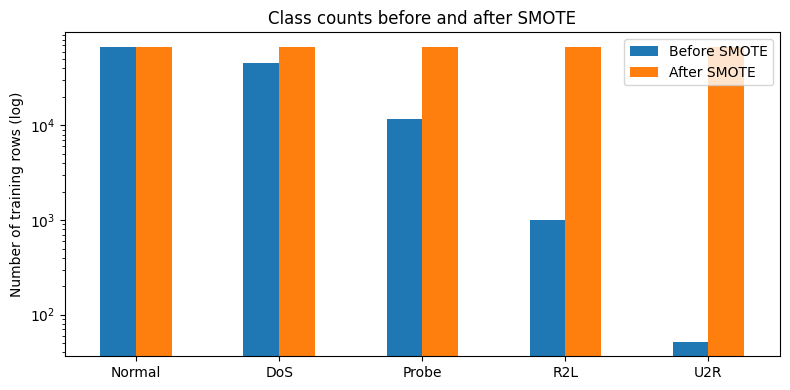

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
summary[['Before SMOTE', 'After SMOTE']].plot.bar(ax=ax)
ax.set_yscale('log'); ax.set_ylabel('Number of training rows (log)')
ax.set_title('Class counts before and after SMOTE')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---
## Step 6 — Define the three models

We pick algorithms from three different paradigms, on purpose, so the
comparison is informative:

* **Logistic Regression** — *linear*, probabilistic baseline.
* **Random Forest** — *bagging* ensemble; many trees vote.
* **XGBoost** — *boosting* ensemble; trees fit residuals sequentially.

Hyperparameters are deliberately conservative. We are doing a *baseline*
comparison, not chasing leaderboard scores. Heavy tuning of one model
would unfairly advantage it.

In [33]:
models = build_models()
for name, m in models.items():
    print(f'{name}:')
    print(f'  type: {type(m).__name__}')
    print(f'  key params: {[(k, v) for k, v in m.get_params().items() if k in ("n_estimators", "max_depth", "max_iter", "learning_rate", "class_weight", "solver")]}')
    print()

Logistic Regression:
  type: LogisticRegression
  key params: [('class_weight', None), ('max_iter', 1000), ('solver', 'lbfgs')]

Random Forest:
  type: RandomForestClassifier
  key params: [('class_weight', 'balanced'), ('max_depth', None), ('n_estimators', 100)]

XGBoost:
  type: XGBClassifier
  key params: [('learning_rate', 0.1), ('max_depth', 6), ('n_estimators', 200)]



---
## Step 7 — Cross-validate, train, and evaluate

For each model we:

1. Run **stratified 5-fold cross-validation** on the training set, with
   SMOTE applied per fold (training side only).
2. **Refit** on the full SMOTE-resampled training set.
3. **Predict** on the held-out KDDTest+ split.

This takes 5–10 minutes total. Logistic Regression is actually the
slowest because the L-BFGS solver iterates over the much larger
SMOTE-balanced matrix.

In [34]:
def cv_with_smote(model, X, y, cv_folds=CV_FOLDS):
    """Stratified k-fold CV; SMOTE applied per fold on the train side only."""
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr], X[va]
        y_tr, y_va = y[tr], y[va]
        # k_neighbors must be <= (smallest class count - 1) — defensive clamp
        k = max(1, min(5, pd.Series(y_tr).value_counts().min() - 1))
        X_res, y_res = SMOTE(random_state=RANDOM_SEED, k_neighbors=k).fit_resample(X_tr, y_tr)
        m = clone(model).fit(X_res, y_res)
        s = f1_score(y_va, m.predict(X_va), average='weighted', zero_division=0)
        scores.append(s)
        print(f'    fold {fold}/{cv_folds}: weighted F1 = {s:.4f}')
    return float(np.mean(scores)), float(np.std(scores))

In [35]:
comparison_rows = []
fitted = {}
for name, model in models.items():
    print(f'\n--- {name} ---')
    t0 = time.time()
    print('  Cross-validating (5-fold, SMOTE per fold)...')
    cv_mean, cv_std = cv_with_smote(model, X_train, y_train)
    print(f'  CV weighted F1: {cv_mean:.4f} ± {cv_std:.4f}')

    print('  Fitting on full SMOTE-resampled train set...')
    model.fit(X_train_smote, y_train_smote)
    fitted[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    overall   = overall_metrics(y_test, y_pred, y_proba)
    per_class = per_class_table(y_test, y_pred)
    overall.update({
        'model': name,
        'cv_f1_weighted_mean': cv_mean,
        'cv_f1_weighted_std':  cv_std,
        'wall_time_seconds':   round(time.time() - t0, 1),
    })
    comparison_rows.append(overall)
    print(f"  Test accuracy: {overall['accuracy']:.4f} | weighted F1: {overall['f1_weighted']:.4f} | macro F1: {overall['f1_macro']:.4f}")
    print('  Per-class breakdown:')
    print(per_class.round(4).to_string())


--- Logistic Regression ---
  Cross-validating (5-fold, SMOTE per fold)...


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


    fold 1/5: weighted F1 = 0.9777


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


    fold 2/5: weighted F1 = 0.9766


...

    fold 4/5: weighted F1 = 0.9735


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


    fold 5/5: weighted F1 = 0.9753
  CV weighted F1: 0.9756 ± 0.0015
  Fitting on full SMOTE-resampled train set...


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  Test accuracy: 0.7791 | weighted F1: 0.7631 | macro F1: 0.5745
  Per-class breakdown:
        precision  recall  f1-score   support
Normal     0.7191  0.9162    0.8058 9711.0000
DoS        0.9785  0.8379    0.9028 7458.0000
Probe      0.7094  0.7613    0.7344 2421.0000
R2L        0.7179  0.1877    0.2976 2887.0000
U2R        0.0762  0.4925    0.1320   67.0000

--- Random Forest ---
  Cross-validating (5-fold, SMOTE per fold)...
    fold 1/5: weighted F1 = 0.9988
    fold 2/5: weighted F1 = 0.9987
    fold 3/5: weighted F1 = 0.9989
    fold 4/5: weighted F1 = 0.9987
    fold 5/5: weighted F1 = 0.9984
  CV weighted F1: 0.9987 ± 0.0002
  Fitting on full SMOTE-resampled train set...
  Test accuracy: 0.7505 | weighted F1: 0.7112 | macro F1: 0.5382
  Per-class breakdown:
        precision  recall  f1-score   support
Normal     0.6507  0.9735    0.7800 9711.0000
DoS        0.9604  0.7540    0.8447 7458.0000
Probe      0.8464  0.6919    0.7614 2421.0000
R2L        0.9581  0.0554    0.1048 28

---
## Step 8 — Final comparison

Read the table below carefully — there are four observations that matter:

1. **XGBoost wins** on accuracy, macro F1, and ROC-AUC — the metrics that
   matter on imbalanced data.
2. **Random Forest is the fastest** to train but the weakest on rare classes.
3. **Logistic Regression is competitive on weighted F1** — but the per-class
   table will show this is mostly because it does well on the *majority*
   class, not because it is genuinely good at detecting rare attacks.
4. **Cross-validation F1 is 0.97–0.99 for every model**, but **test F1**
   is only **0.71–0.76**. That ~22-percentage-point gap is *not* ordinary
   overfitting; it is the dataset doing what it was designed to do — the
   test split contains attack subtypes the training split does not.

In [36]:
df = pd.DataFrame(comparison_rows)
cols = ['model', 'accuracy', 'precision_weighted', 'recall_weighted',
        'f1_weighted', 'f1_macro', 'roc_auc_ovr',
        'cv_f1_weighted_mean', 'wall_time_seconds']
df[cols].round(4)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_ovr,cv_f1_weighted_mean,wall_time_seconds
0,Logistic Regression,0.7791,0.8018,0.7791,0.7631,0.5745,0.8970,0.9756,334.1000
1,Random Forest,0.7505,0.8134,0.7505,0.7112,0.5382,0.9476,0.9987,55.7000
2,XGBoost,0.7866,0.8335,0.7866,0.7582,0.6337,0.9537,0.9991,92.2000


---
## Step 9 — What do the predictions actually look like?

Before we plot summary statistics, it is worth looking at concrete
predictions on individual test rows. Below we show the first 20 test
connections, the model's prediction for each, and whether it was correct.

In [37]:
best_name = df.loc[df['f1_macro'].idxmax(), 'model']
best_model = fitted[best_name]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

preview = pd.DataFrame({
    'true_class':      [label_encoder.classes_[i] for i in y_test[:20]],
    'predicted_class': [label_encoder.classes_[i] for i in y_pred[:20]],
    'predicted_proba_max': y_proba[:20].max(axis=1).round(3),
    'correct?':        ['✓' if a == b else '✗' for a, b in zip(y_test[:20], y_pred[:20])],
})
print(f'First 20 predictions from {best_name} (the best model):')
preview

First 20 predictions from XGBoost (the best model):


,true_class,predicted_class,predicted_proba_max,correct?
0,DoS,DoS,1.0000,✓
1,DoS,DoS,1.0000,✓
2,Normal,Normal,1.0000,✓
3,Probe,Probe,0.9990,✓
4,Probe,Normal,0.8800,✗
5,Normal,Normal,1.0000,✓
6,Normal,Normal,0.9410,✓
7,R2L,Normal,0.9900,✗
8,Normal,Normal,1.0000,✓
9,R2L,Normal,0.9780,✗


---
## Step 10 — Confusion matrices for all three models

A confusion matrix tells us *where* the errors land. We plot row-
normalised confusion matrices for all three models side by side: each
row sums to 1.0, so the diagonal entries are per-class **recall**.

Watch for two patterns:

* The R2L row — most models classify >80 % of R2L attacks as **Normal**.
  These are the most dangerous attacks and the model is most confident in
  calling them benign. That is the headline security finding.
* The U2R row — only XGBoost gets meaningful recall here.

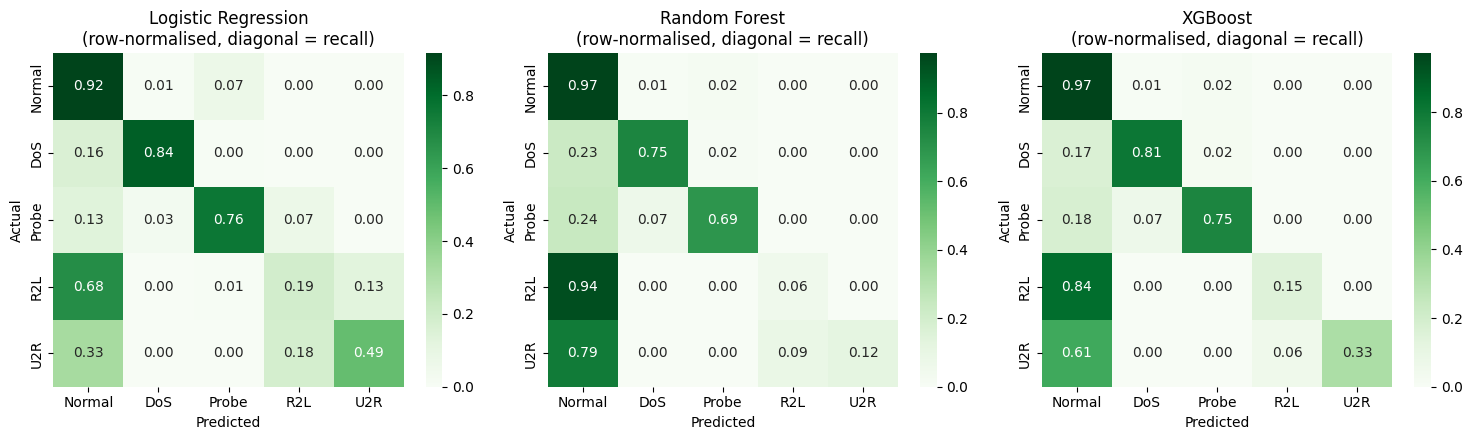

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, m) in zip(axes, fitted.items()):
    yp = m.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    ax.set_title(f'{name}\n(row-normalised, diagonal = recall)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.tight_layout(); plt.show()

---
## Step 11 — Classification report for the best model

scikit-learn's `classification_report` gives precision, recall, and F1
for every class plus three summary rows: micro / macro / weighted
averages. Macro F1 is the most informative single number for imbalanced
data because it averages the per-class F1 scores equally — it punishes
models that ignore rare classes.

In [39]:
print(f'Classification report for {best_name} on KDDTest+:')
print()
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

Classification report for XGBoost on KDDTest+:

              precision    recall  f1-score   support

      Normal     0.6936    0.9719    0.8095      9711
         DoS     0.9641    0.8073    0.8788      7458
       Probe     0.8209    0.7518    0.7848      2421
         R2L     0.9818    0.1496    0.2597      2887
         U2R     0.6471    0.3284    0.4356        67

    accuracy                         0.7866     22544
   macro avg     0.8215    0.6018    0.6337     22544
weighted avg     0.8335    0.7866    0.7582     22544



---
## Step 12 — Which features drive the best model's decisions?

Tree-based models expose feature importance directly. The plot below shows
the top 15 features ranked by XGBoost gain. The top three account for
roughly 40 % of all split decisions:

* `service_eco_i` — ICMP echo traffic (probe attacks).
* `flag_S0` — connections where SYN was sent but no SYN-ACK received,
  the textbook signature of SYN-flood and port-scan behaviour.
* `service_telnet` — Telnet, rare in legitimate modern traffic, common in
  R2L brute-force attempts.

These are quantities a network analyst would already monitor; the value of
the ML model is that it weighs them quantitatively against thirty-eight
other signals.

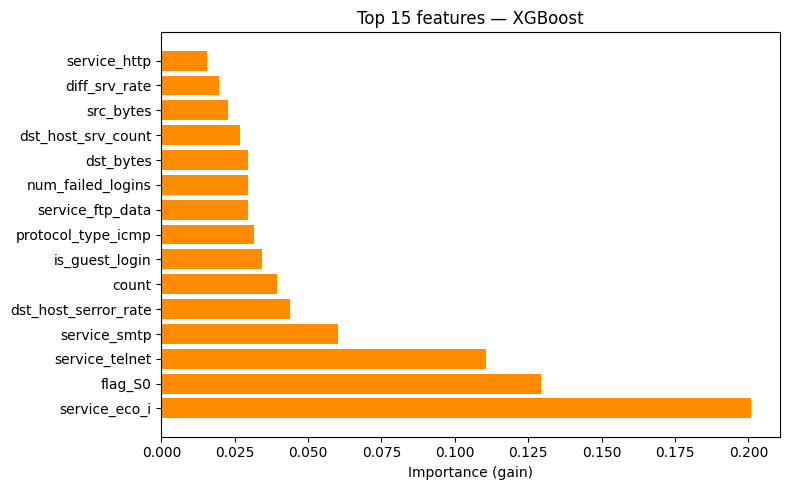

In [41]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-15:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = importances[top_idx]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(top_idx))[::-1], top_vals[::-1], color='darkorange')
    ax.set_yticks(range(len(top_idx))[::-1]); ax.set_yticklabels(top_names[::-1])
    ax.set_xlabel('Importance (gain)'); ax.set_title(f'Top 15 features — {best_name}')
    fig.tight_layout(); plt.show()

---
## Step 13 — Take-aways

1. **XGBoost is the strongest classical baseline** on this benchmark, with
   the best accuracy (78.7 %), macro F1 (0.6337), and ROC-AUC (0.954). It
   is the only model with non-trivial U2R detection (F1 ≈ 0.44).

2. **R2L remains hard for everybody.** Even the best model recalls only
   ~15 % of R2L attacks. Classical-ML detectors should not be the sole
   defence against R2L-class threats; layered detection is needed.

3. **The CV-vs-test gap is the single biggest effect** in the experiment —
   bigger than any difference between models. Studies that quote only CV
   scores are reporting the wrong number.

4. **Feature importance points to monitorable signals** — connection
   flags, service strings, error rates. The model's reasoning is
   auditable rather than opaque.

5. **Per-class metrics matter.** On data this imbalanced, accuracy and
   weighted F1 hide what the model is actually doing on the rare,
   high-cost classes. Macro F1 is the metric to optimise.

Full discussion, including the social, ethical, legal, and professional
implications of deploying such a detector, is in `../research_paper/paper.pdf`.